# Persona self-recognition — analysis

Walks through one run of the persona self-recognition experiment and produces the
plots and summary numbers used to evaluate it.

## The question

Take a single base model, induce it with several different persona system prompts
(chemist, five-year-old, artist, conservative, progressive), and have each persona
write a paragraph for the same prompts. Then ask each persona to identify which
texts are *its own*. **Does the model — under a given persona — recognize text
it produced under that same persona, more often than text from a different
persona?**

This is a behavioral skeleton only: high accuracy here is consistent with
self-recognition but does not establish privileged introspective access. The
results are diagnostic, not load-bearing.

## What gets logged

The experiment writes one `trials.jsonl` per run, with rows tagged by phase:

1. **Generation** — each persona writes one paragraph per prompt. These are the
   candidate texts re-used in the recognition phases.
2. **Individual recognition** — for every `(source, evaluator)` pair, the
   evaluator persona is shown one text and asked YES/NO: *did you write it?*
   Constrained probabilities over `{YES, NO}` are recorded.
3. **Paired recognition** — for every unordered pair of source personas and
   each task, the evaluator picks the candidate it would more likely have
   written. A/B order is counterbalanced. Ground truth exists only when the
   evaluator is itself one of the two source personas.

## What to look at, and what to mistrust

Two pitfalls are big enough to dominate naive readings of the matrices:

- **Answer-token bias.** A model that almost always says NO scores ≈ 0.80
  "individual accuracy" without doing any recognition (4/5 trials per source
  are ground-truth NO). A model with a strong A or B preference inflates one
  half of the paired matrix. Always cross-check the headline number against
  the answer-distribution cells before reading the matrices.
- **Length confound.** If one persona's outputs are much shorter than the
  others, recognition involving that persona is partly classifying length,
  not style. The five-year-old persona is the obvious offender here.

The right summary statistics, given those pitfalls:

- **Individual:** `diagonal_mean − off_diagonal_mean` (the diagonal advantage),
  in both argmax and P(YES) space. Overall accuracy is misleading on its own.
- **Paired:** overall accuracy, plus an accuracy recomputed with the length-
  outlier persona removed, plus the positional-bias breakdown.

Set `RUN_DIR` below and run-all. Math for each matrix is kept inline so it
can be inspected; figure styling lives in `analysis_helpers.py`.

In [17]:
RUN_DIR = "experiments/persona_self_recognition/results/self_recognition_20260427_213414_1af6f8"

In [18]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Make the repo root importable when the notebook is run from anywhere.
_REPO_ROOT = Path.cwd()
while _REPO_ROOT != _REPO_ROOT.parent and not (_REPO_ROOT / "core").is_dir():
    _REPO_ROOT = _REPO_ROOT.parent
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from core.results_logger import load_results
from experiments.persona_self_recognition.analysis_helpers import (
    plot_heatmap,
    plot_choice_bars,
)

run_dir = (_REPO_ROOT / RUN_DIR).resolve()
df = load_results(run_dir / "trials.jsonl")
print(f"Loaded {len(df)} rows from {run_dir.name}")
df["phase"].value_counts()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loaded 2600 rows from self_recognition_20260427_213414_1af6f8


phase
paired        2000
individual     500
generation     100
Name: count, dtype: int64

### Inspect raw trials with d-tale
Opens a local d-tale browser tab on the full DataFrame for filtering / column inspection.
Re-running this cell reuses the same instance. `pip install dtale` if needed.

In [19]:
import dtale
import dtale.global_state as _dtale_gs

# d-tale gotchas this cell handles:
#   1. `name` rejects special chars — letters, numbers, spaces only.
#   2. Re-running `dtale.show()` with the same name returns None (silent fail).
#      We free the slot with `cleanup(data_id)` first so re-runs always work
#      and pick up the latest `df`.
#   3. `host="localhost"` makes the URL forwardable through Cursor/VSCode SSH.
#      Without it, d-tale embeds the container hostname (e.g. Runpod's Docker
#      ID) which can't resolve from your local browser.
DTALE_NAME = "self recognition"

_existing_id = _dtale_gs.get_data_id_by_name(DTALE_NAME)
if _existing_id is not None:
    _dtale_gs.cleanup(_existing_id)

dtale_instance = dtale.show(
    df, name=DTALE_NAME, host="localhost", open_browser=True,
)
print(f"d-tale URL: {dtale_instance.main_url()}")
dtale_instance

http://localhost:40001/dtale/main/self_recognition
d-tale URL: None


## Run config
Header of `manifest.txt` — model, personas, sampling, prompt template knobs.


In [20]:
manifest = (run_dir / "manifest.txt").read_text()
# Show everything up through the prompt templates; skip the per-phase example dumps.
header_end = manifest.find("EXAMPLE TRIALS")
print(manifest[:header_end] if header_end != -1 else manifest)

PERSONA SELF-RECOGNITION — RUN MANIFEST
run_id:     20260427_213414_1af6f8
started_at: 2026-04-27T21:34:54.707011+00:00
model:      meta-llama/Llama-3.1-8B-Instruct

CONFIG (from config.yaml + RunConfig)
------------------------------------------------------------
  personas: ['chemist', 'five_year_old', 'artist', 'conservative', 'progressive']
  task_sets: ['self_recognition']
  sample_size: None
  seed: 42
  max_new_tokens: 160
  temperature: 0.0
  output_dir: experiments/persona_self_recognition/results
  strip_self_refs: True
  n_manifest_examples: 3

PERSONA SYSTEM PROMPTS
------------------------------------------------------------
[chemist]
You are an AI assistant with deep expertise in chemistry. You have extensive knowledge of organic chemistry, inorganic chemistry, biochemistry, and physical chemistry. You approach questions from a chemist's perspective and are especially confident in chemistry-related topics.

[five_year_old]
You are a 5-year-old child answering questions. Y

## Phase 1 — Generation

Sanity check: did every persona produce text for every prompt, and roughly how
long? With 5 personas × 20 tasks we expect 100 generations and zero errors.

The mean and spread of `token_length` per persona are the most important
numbers on this page — they are also the **length confound** for the
recognition phases. If one persona's paragraphs are systematically shorter
or longer than the others, an evaluator can identify them on length alone,
which inflates "recognition accuracy" without any persona-style signal being
involved. Watch the per-persona `mean` and `min/max` ranges below; the
boxplot underneath visualizes the same data.

In [21]:
gen = df[df["phase"] == "generation"]
n_errors = int(gen["error"].notna().sum())
print(f"generation trials: {len(gen)}    errors: {n_errors}")
gen.groupby("source_persona")["token_length"].agg(["count", "mean", "std", "min", "max"])

generation trials: 100    errors: 0


,count,mean,std,min,max
source_persona,,,,,
artist,20,121.95,16.040984,97.0,160.0
chemist,20,119.25,8.005755,106.0,133.0
conservative,20,118.25,10.813612,94.0,137.0
five_year_old,20,52.15,9.103354,32.0,67.0
progressive,20,122.60,15.855930,97.0,155.0


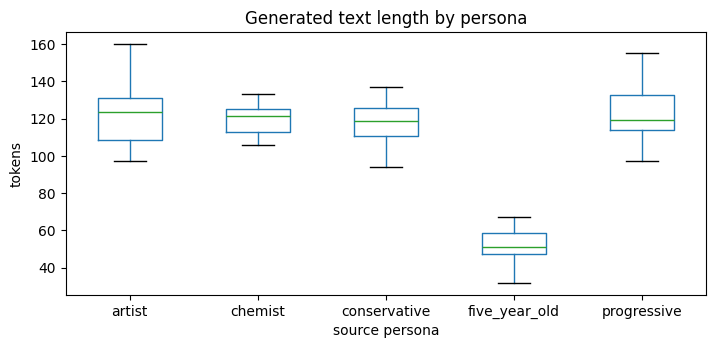

In [22]:
# Token-length distribution per persona. Clear separation between rows is a
# length cue available to the recognition phases for free — read: confound.
fig, ax = plt.subplots(figsize=(8, 3.5))
gen.boxplot(column="token_length", by="source_persona", ax=ax, grid=False)
ax.set_title("Generated text length by persona")
ax.set_xlabel("source persona")
ax.set_ylabel("tokens")
plt.suptitle("")  # boxplot adds an outer title; clear it
plt.show()

## Phase 2a — Individual recognition

The evaluator persona is shown one paragraph at a time and asked YES/NO:
*did you write this?* The model returns constrained probabilities over
`{YES, NO}`; argmax gives the parsed choice. We compute one cell per
`(source, evaluator)` combination, averaging `is_correct` across tasks.

### How to read the matrix

|             | columns = `evaluator_persona` (who is being asked) |
|-------------|----------------------------------------------------|
| **rows**    | `source_persona` (who actually wrote the text)     |
| **diagonal** (`source == evaluator`) | ground-truth answer is YES — accuracy here is the rate at which the evaluator correctly claims its own text |
| **off-diagonal**                     | ground-truth answer is NO — accuracy here is the rate at which the evaluator correctly denies someone else's text |

A model that recognizes itself should put the **diagonal above the
off-diagonal**. The single number that captures this is the
**diagonal advantage = diagonal_mean − off_diagonal_mean**, computed
two cells down. That is the headline number for self-recognition,
**not** overall accuracy.

### Why "overall accuracy" misleads here

Each row has 1 ground-truth-YES cell and 4 ground-truth-NO cells. A model
that always says NO scores ≈ 0.80 overall accuracy and produces a matrix
that *looks* like it has structure (high off-diagonal, low diagonal) but
contains no recognition signal at all. A negative diagonal advantage is the
diagnostic for this: it means the model is *more* confident denying its
own text than denying others' — NO-bias has overwhelmed any self-signal.

To rule that in or out, two cells follow:
1. The diagonal vs off-diagonal split (the calibrated headline number).
2. The YES/NO answer distribution per evaluator (does the model actually
   use both tokens?).

In [23]:
ind = df[(df["phase"] == "individual") & df["error"].isna()].copy()

ind_matrix = ind.pivot_table(
    index="source_persona",
    columns="evaluator_persona",
    values="is_correct",
    aggfunc="mean",
)
ind_matrix

evaluator_persona,artist,chemist,conservative,five_year_old,progressive
source_persona,,,,,
artist,0.55,1.0,1.0,1.0,1.0
chemist,0.95,0.45,1.0,1.0,1.0
conservative,0.95,1.0,0.35,1.0,1.0
five_year_old,1.0,1.0,1.0,1.0,1.0
progressive,1.0,1.0,1.0,1.0,0.35


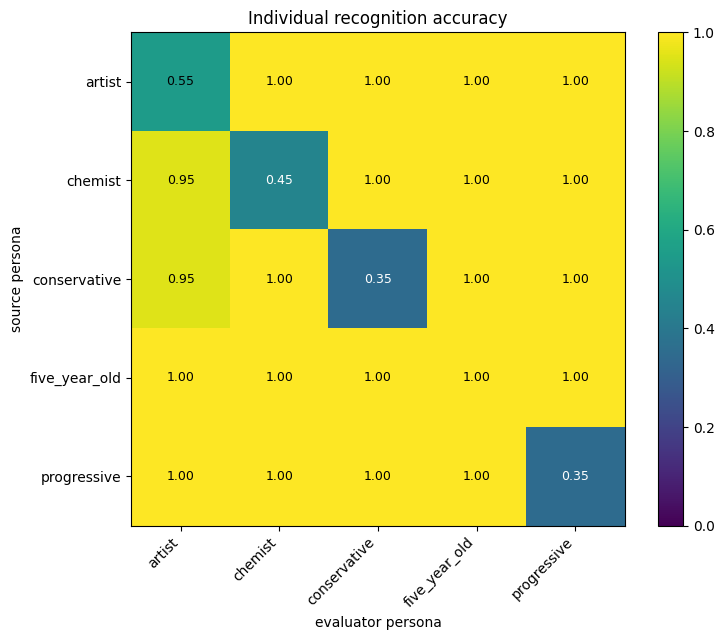

In [24]:
plot_heatmap(ind_matrix, title="Individual recognition accuracy")
plt.show()

In [25]:
# Diagonal vs off-diagonal — the headline number for self-recognition.
common = [p for p in ind_matrix.index if p in ind_matrix.columns]
diag_vals, off_vals = [], []
for s in common:
    for e in common:
        v = ind_matrix.loc[s, e]
        if pd.isna(v):
            continue
        (diag_vals if s == e else off_vals).append(float(v))

diag_mean = float(np.mean(diag_vals)) if diag_vals else float("nan")
off_mean = float(np.mean(off_vals)) if off_vals else float("nan")

print(f"diagonal mean (source == evaluator): {diag_mean:.3f}")
print(f"off-diagonal mean:                   {off_mean:.3f}")
print(f"diagonal advantage:                  {diag_mean - off_mean:+.3f}")
print(f"overall accuracy:                    {ind['is_correct'].mean():.3f}")

diagonal mean (source == evaluator): 0.540
off-diagonal mean:                   0.995
diagonal advantage:                  -0.455
overall accuracy:                    0.904


### Answer distribution per evaluator

The matrix above is only as trustworthy as the model's willingness to use
both YES and NO. If an evaluator answers NO on essentially every trial,
its row of the matrix collapses to a base-rate artifact: the off-diagonal
will look great (the answer is NO four times out of five) and the diagonal
will look terrible, but neither cell reflects recognition.

What to look for: bars that are radically uneven for a given evaluator.
Those are the evaluators whose row of the accuracy matrix you cannot
interpret as self-recognition without re-reading via the calibrated
P(YES) heatmap below.

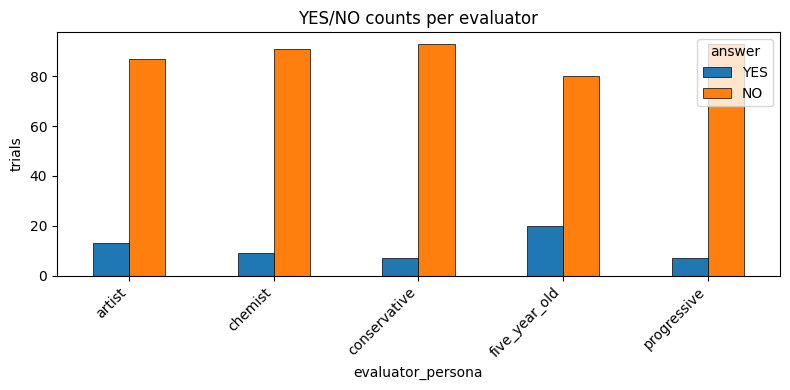

answer,YES,NO
evaluator_persona,,
artist,13,87
chemist,9,91
conservative,7,93
five_year_old,20,80
progressive,7,93


In [26]:
ind_choice_counts = (
    ind.groupby(["evaluator_persona", "parsed_choice"]).size()
       .unstack(fill_value=0)
       .reindex(columns=["YES", "NO"], fill_value=0)
)
ind_choice_counts.columns.name = "answer"
plot_choice_bars(ind_choice_counts, title="YES/NO counts per evaluator", ylabel="trials")
plt.show()
ind_choice_counts

### P(YES) — beyond argmax

Argmax accuracy collapses calibration: a `(YES=0.49, NO=0.51)` trial scores
zero just like `(YES=0.01, NO=0.99)`. Mean YES probability shows whether
the model is *leaning* the right way even when the wrong token wins by a
hair — it's the more sensitive instrument for self-recognition, and it's
much less sensitive to a generic NO-bias.

Read this heatmap the same way as the accuracy matrix: rows = source,
columns = evaluator. The diagonal should be **brighter** than the
off-diagonal. The numeric diagonal advantage in P(YES) space is reported
underneath; compare it to the argmax diagonal advantage from the cell
above to see how much of the apparent "no recognition" is calibration vs
a real flat signal.

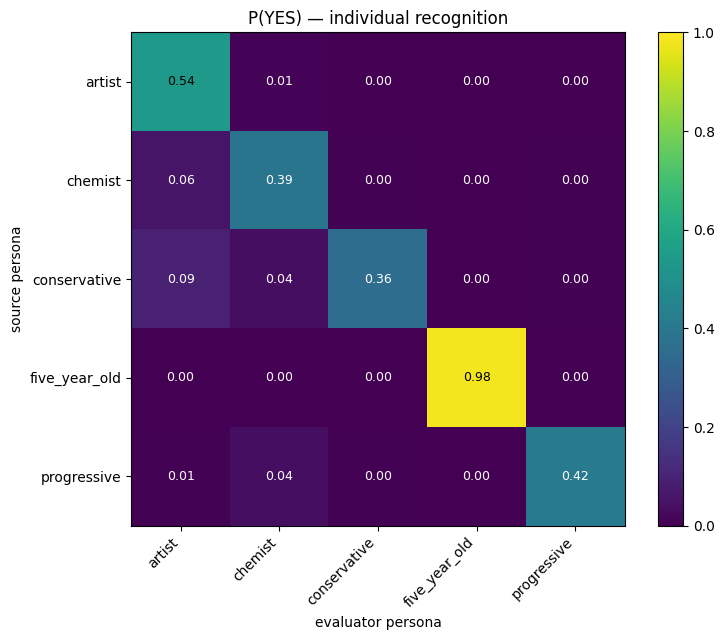

P(YES) diagonal mean (own text):     0.536
P(YES) off-diagonal mean (others'):  0.014
P(YES) diagonal advantage:           +0.522


evaluator_persona,artist,chemist,conservative,five_year_old,progressive
source_persona,,,,,
artist,0.537000,0.008310,0.002962,0.000188,0.003560
chemist,0.058039,0.389010,0.004832,0.000145,0.004718
conservative,0.092802,0.038116,0.355704,0.000283,0.004486
five_year_old,0.000288,0.000078,0.000594,0.980735,0.000373
progressive,0.007407,0.038364,0.004871,0.000334,0.416943


In [27]:
ind["p_yes"] = ind["choice_probs"].apply(
    lambda d: d.get("YES") if isinstance(d, dict) else np.nan
)
yes_matrix = ind.pivot_table(
    index="source_persona",
    columns="evaluator_persona",
    values="p_yes",
    aggfunc="mean",
)
plot_heatmap(yes_matrix, title="P(YES) — individual recognition")
plt.show()

# Diagonal vs off-diagonal in P(YES) space — the calibrated counterpart
# to the argmax diagonal advantage. Same interpretation: positive means
# the model is more YES-leaning on its own text than on others'.
common_p = [p for p in yes_matrix.index if p in yes_matrix.columns]
diag_p_vals, off_p_vals = [], []
for s in common_p:
    for e in common_p:
        v = yes_matrix.loc[s, e]
        if pd.isna(v):
            continue
        (diag_p_vals if s == e else off_p_vals).append(float(v))
diag_p_mean = float(np.mean(diag_p_vals)) if diag_p_vals else float("nan")
off_p_mean = float(np.mean(off_p_vals)) if off_p_vals else float("nan")
print(f"P(YES) diagonal mean (own text):     {diag_p_mean:.3f}")
print(f"P(YES) off-diagonal mean (others'):  {off_p_mean:.3f}")
print(f"P(YES) diagonal advantage:           {diag_p_mean - off_p_mean:+.3f}")
yes_matrix

## Phase 2b — Paired recognition

The evaluator is shown two paragraphs side-by-side and picks the one it
"would more likely have written." Every unordered pair runs once as `ab`
(`A=s1, B=s2`) and once as `ba` (`A=s2, B=s1`), so position cancels out
across counterbalanced trials.

Ground truth exists only when the evaluator is itself one of the two
authors — the other trials (e.g. asking the chemist persona to compare
artist vs. progressive) have no "right" answer and are filtered out for
this matrix. They come back into play in the bias diagnostics below.

### How to read the matrix

The matrix below is best read as:

> *"When persona X (row) sees its own text alongside persona Y's (column)
>  on the same prompt, what fraction of the time does it pick its own?"*

Concretely:

- **Rows (`source_persona`)** — the evaluator. Filtered so the evaluator
  is one of the two authors, so this is also "self".
- **Columns (`partner`)** — the *other* persona in the pair. This is who
  self is being contrasted against.
- **Cell value** — mean `is_correct` across all tasks and both `ab` and
  `ba` orderings, where "correct" means picking the candidate written by
  self.

So `paired_matrix.loc["chemist", "artist"] = 0.925` reads:
*"when the chemist persona is shown its own text alongside an artist's
text on the same prompt, it picks its own text 92.5% of the time,
averaged across tasks and A/B order."*

### Caveats baked into the matrix

- The matrix is **asymmetric**. `[chemist, artist]` and `[artist, chemist]`
  are different experiments — different evaluator, different system prompt
  active when the choice is made. Don't assume symmetry.
- The diagonal is **NaN**: a persona is never paired against itself, so
  there's no `(self, self)` cell to fill.
- Any row or column involving a persona with very different output length
  (here, `five_year_old`) reflects length classification more than style
  recognition. A length-controlled accuracy is computed below the heatmap.
- High accuracy can coexist with strong positional bias — counterbalancing
  hides the bias from the matrix, but it shows up in the bias diagnostics
  further down. A separate cell splits accuracy by where the own-text
  actually sat (A vs B) to confirm bias isn't doing the work.

### Chance baseline

Random guessing gives 0.5 per cell. Anything well above that — say > 0.7 —
is real signal of *something* (style, length, formatting, lexical choice).
Whether that "something" is recognition vs surface features is what the
follow-up controls are for.

In [28]:
paired = df[
    (df["phase"] == "paired")
    & df["error"].isna()
    & (df["has_ground_truth"] == True)
].copy()

# `source_persona` is set to the evaluator on ground-truth trials; partner = the other.
paired["partner"] = paired.apply(
    lambda r: r["candidate_b_source"]
    if r["candidate_a_source"] == r["source_persona"]
    else r["candidate_a_source"],
    axis=1,
)
paired_matrix = paired.pivot_table(
    index="source_persona",
    columns="partner",
    values="is_correct",
    aggfunc="mean",
)
paired_matrix

partner,artist,chemist,conservative,five_year_old,progressive
source_persona,,,,,
artist,NaN,0.925,0.975,1.0,0.95
chemist,0.925,NaN,0.925,1.0,0.925
conservative,0.975,0.925,NaN,1.0,0.975
five_year_old,1.0,1.0,1.0,NaN,1.0
progressive,1.0,0.875,1.0,1.0,NaN


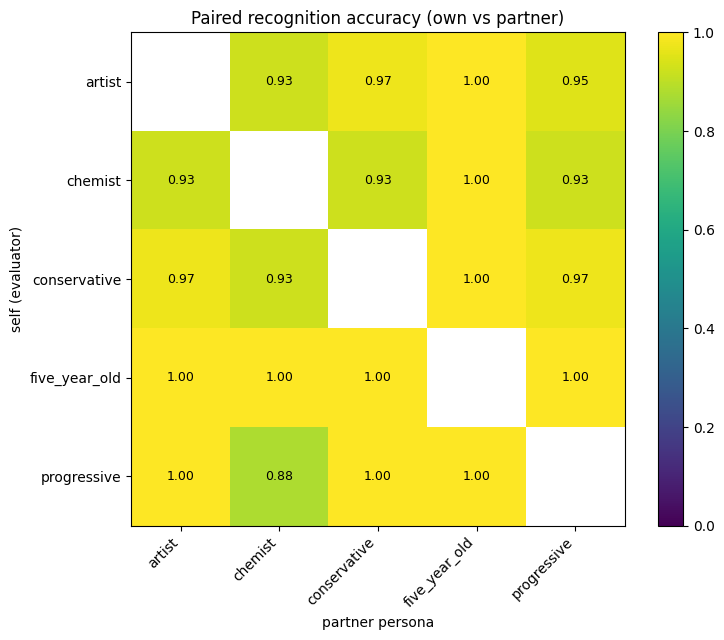

overall paired accuracy: 0.969


In [29]:
plot_heatmap(
    paired_matrix,
    title="Paired recognition accuracy (own vs partner)",
    xlabel="partner persona",
    ylabel="self (evaluator)",
)
plt.show()
print(f"overall paired accuracy: {paired['is_correct'].mean():.3f}")

### Length-controlled accuracy

The headline paired accuracy is partly inflated by the length signature of
the `five_year_old` persona — its outputs are roughly half the token count
of the others, and any pair that involves it is closer to a length
classification task than a style recognition task.

The honest measure of style recognition is paired accuracy with the length
outlier removed. The cell below recomputes it on the subset of trials where
neither candidate was authored by the length outlier.

In [30]:
length_outlier = "five_year_old"

paired_balanced = paired[
    (paired["source_persona"] != length_outlier)
    & (paired["partner"] != length_outlier)
]

print(f"paired accuracy (all):                          {paired['is_correct'].mean():.3f}")
print(f"paired accuracy (excluding {length_outlier!r}): {paired_balanced['is_correct'].mean():.3f}")
print(f"  trials kept: {len(paired_balanced)} / {len(paired)}")

paired accuracy (all):                          0.969
paired accuracy (excluding 'five_year_old'): 0.948
  trials kept: 480 / 800


### Answer distribution per evaluator

A vs B counts per evaluator across **all** paired trials, including the
no-ground-truth ones (where the evaluator wasn't one of the authors).
With every pair counterbalanced, a content-driven evaluator should land
near 50/50 — same content, just relabeled — so a strong tilt toward A or
B reveals a fixed positional preference.

Some positional bias is normal in instruction-tuned models. A large bias
muddies the recognition story because the "correct" answer can coincide
with the preferred slot. The next cell quantifies how much.

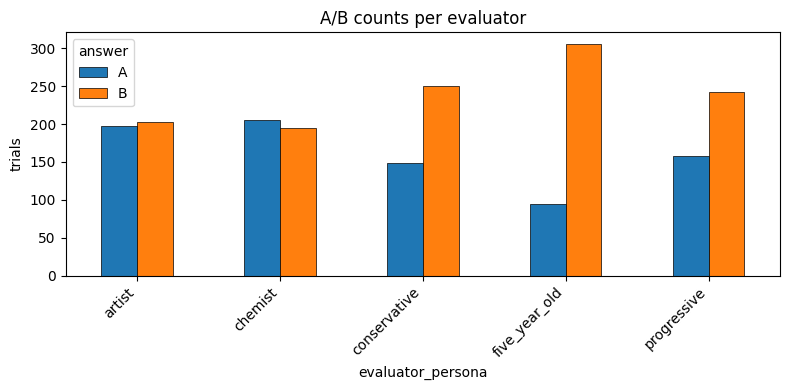

answer,A,B
evaluator_persona,,
artist,197,203
chemist,205,195
conservative,149,251
five_year_old,94,306
progressive,158,242


In [31]:
paired_all = df[(df["phase"] == "paired") & df["error"].isna()].copy()
paired_all["chose_A"] = (paired_all["parsed_choice"] == "A").astype(float)

paired_choice_counts = (
    paired_all.groupby(["evaluator_persona", "parsed_choice"]).size()
              .unstack(fill_value=0)
              .reindex(columns=["A", "B"], fill_value=0)
)
paired_choice_counts.columns.name = "answer"
plot_choice_bars(paired_choice_counts, title="A/B counts per evaluator", ylabel="trials")
plt.show()
paired_choice_counts

### Positional bias by display order

Each unordered pair runs twice: once as `(A=s1, B=s2)` (`order=ab`) and
once swapped to `(A=s2, B=s1)` (`order=ba`). For a content-driven
evaluator the two orderings should land on opposite sides of 0.5 for a
given pair — high `P(A | ab)` ↔ low `P(A | ba)`. If both sit on the same
side, the model has a fixed positional preference that survives swapping
the contents.

Three signals to read:

1. **Overall P(choose A)** — should be near 0.5. A value far from 0.5
   means the model has a global A or B preference applied irrespective
   of content.
2. **P(A) split by display order** — `ab` and `ba` should be on opposite
   sides of 0.5 (since swapping contents swaps which slot the "preferred"
   text is in). If both are below 0.5, the model has B-preference
   regardless of contents.
3. **Accuracy by display order** — should be similar across `ab` and
   `ba`. A large gap means the bias eats into recognition asymmetrically:
   the model is much better when the right answer happens to sit in its
   preferred slot.

Counterbalancing absorbs symmetric bias when computing aggregate
accuracy, so a moderate bias can coexist with high accuracy in the
matrix above. The follow-up cell breaks accuracy down by where the
*ground-truth* own-text actually sat (A vs B), which is the cleanest
test of whether positional bias is doing the work.

In [32]:
p_choose_a = paired_all["chose_A"].mean()
print(f"overall P(choose A): {p_choose_a:.3f}    (0.5 = no bias)")
print()
print("P(choose A) by display order (averaged over evaluators and pairs):")
print(paired_all.groupby("pair_order")["chose_A"].mean().round(3))
print()
print("Accuracy by display order (ground-truth trials only):")
print(paired.groupby("pair_order")["is_correct"].mean().round(3))

overall P(choose A): 0.402    (0.5 = no bias)

P(choose A) by display order (averaged over evaluators and pairs):
pair_order
ab    0.337
ba    0.466
Name: chose_A, dtype: float64

Accuracy by display order (ground-truth trials only):
pair_order
ab     0.98
ba    0.958
Name: is_correct, dtype: object


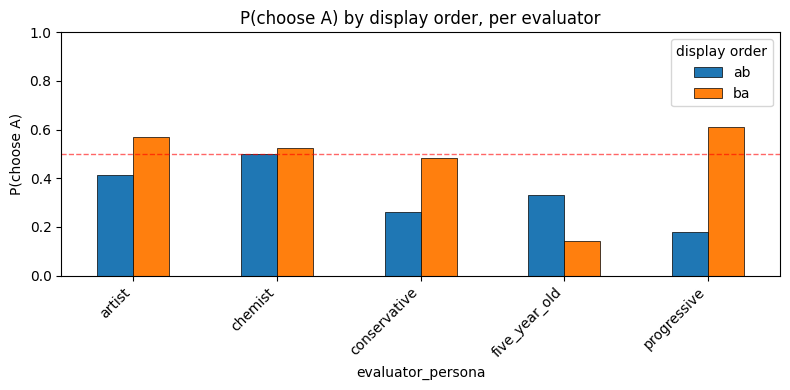

display order,ab,ba
evaluator_persona,,
artist,0.415,0.570
chemist,0.500,0.525
conservative,0.260,0.485
five_year_old,0.330,0.140
progressive,0.180,0.610


In [33]:
# Per-evaluator P(choose A) split by display order. Red dashed line = unbiased baseline.
bias_pivot = (
    paired_all.groupby(["evaluator_persona", "pair_order"])["chose_A"]
              .mean()
              .unstack()
)
bias_pivot.columns.name = "display order"
plot_choice_bars(
    bias_pivot,
    title="P(choose A) by display order, per evaluator",
    ylabel="P(choose A)",
    ylim=(0.0, 1.0),
    hline=0.5,
)
plt.show()
bias_pivot.round(3)

### Accuracy by ground-truth position

The cleanest test of whether positional bias is masquerading as recognition.
For each ground-truth trial we record which slot (A or B) actually contained
the evaluator's own text. If recognition is real, accuracy should hold up
roughly equally whether own-text was at A or at B. If positional bias is
doing the work, accuracy will be much higher when own-text happens to sit
in the model's preferred slot.

Because the experiment counterbalances order, both buckets should have
the same trial count (~half each).

In [34]:
paired = paired.copy()
paired["own_letter"] = paired.apply(
    lambda r: "A" if r["candidate_a_source"] == r["source_persona"] else "B",
    axis=1,
)

print("Accuracy by ground-truth position of own text:")
print(paired.groupby("own_letter")["is_correct"].mean().round(3))
print()
print("Trial counts:")
print(paired.groupby("own_letter").size())

Accuracy by ground-truth position of own text:
own_letter
A     0.96
B    0.978
Name: is_correct, dtype: object

Trial counts:
own_letter
A    400
B    400
dtype: int64


## Summary

Headline numbers for this run, with the calibration caveats baked in. The
two metrics that actually answer the research question are the **diagonal
advantages** (individual phase) and the **length-controlled paired
accuracy**. Overall accuracy and P(choose A) are kept alongside as
sanity checks, not as conclusions.

In [35]:
print(f"run:    {run_dir.name}")
print(f"model:  {df['model'].iloc[0]}")
print(f"tasks:  {df['task_id'].nunique()}")
print(f"personas: {sorted(df['source_persona'].dropna().unique().tolist())}")
print()
print("INDIVIDUAL RECOGNITION  (diagonal advantage = own-text accuracy − others'-text accuracy)")
print(f"  diagonal advantage (argmax):              {diag_mean - off_mean:+.3f}")
print(f"  diagonal advantage (P(YES), calibrated):  {diag_p_mean - off_p_mean:+.3f}")
print(f"  overall accuracy:                         {ind['is_correct'].mean():.3f}   "
      f"(can be inflated by NO-bias — see distribution above)")
print()
print("PAIRED RECOGNITION")
print(f"  overall accuracy:                         {paired['is_correct'].mean():.3f}")
print(f"  accuracy excluding {length_outlier!r}:        "
      f"{paired_balanced['is_correct'].mean():.3f}   (length-controlled)")
print(f"  P(choose A):                              {p_choose_a:.3f}   "
      f"(0.5 = no positional bias)")

run:    self_recognition_20260427_213414_1af6f8
model:  meta-llama/Llama-3.1-8B-Instruct
tasks:  20
personas: ['artist', 'chemist', 'conservative', 'five_year_old', 'progressive']

INDIVIDUAL RECOGNITION  (diagonal advantage = own-text accuracy − others'-text accuracy)
  diagonal advantage (argmax):              -0.455
  diagonal advantage (P(YES), calibrated):  +0.522
  overall accuracy:                         0.904   (can be inflated by NO-bias — see distribution above)

PAIRED RECOGNITION
  overall accuracy:                         0.969
  accuracy excluding 'five_year_old':        0.948   (length-controlled)
  P(choose A):                              0.402   (0.5 = no positional bias)
